# Telecom Customer Churn Analysis

## 02: Univariate Analysis

### Objective
This notebook explores the individual characteristics and distributions of variables in the cleaned Telecom Customer Churn dataset.

The analysis focuses on:
- Understanding the demographic and geographic characteristics of the customer base
- Examining customer tenure and referral behavior
- Evaluating adoption across available services
- Analyzing customer billing and financial characteristics
- Examining the overall distribution of customer status and churn-related attributes

This establishes a baseline understanding of the customer base before investigating relationships between variables and customer churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load output from first notebook
churn_df = pd.read_parquet('../data/processed/telecom_customer_churn_clean.parquet')

In [3]:
# Set visualization settings
sns.set_theme(style='white', context='notebook')
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

colors = {
    'blue': '#1E3A8A',
    'berry': '#D1345B',
    'teal': "#14B8A6",
    'darkblue': '#263252',
    'red': '#ff3f34'
}

## Customer Profile

This section examines the demographic and geographic characteristics of the customer base, along with customer tenure and referral behavior.

### Gender
- What proportion of the customer base does each gender represent?
- Is the customer base balanced across genders?

In [8]:
churn_df['Gender'].value_counts(normalize=True) * 100

Gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

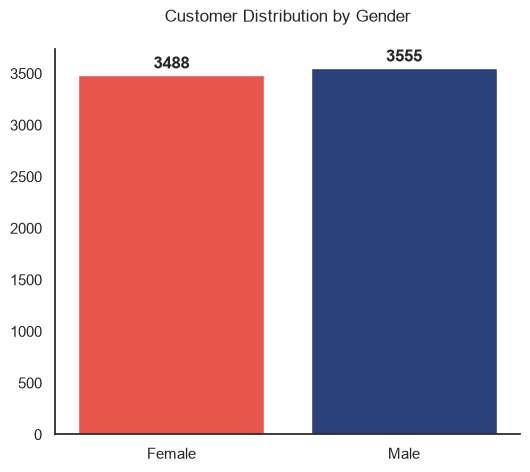

In [11]:
plt.figure(figsize=(6, 5))

ax = sns.countplot(
    churn_df,
    x='Gender',
    hue='Gender',
    dodge=False,
    palette=[colors['red'], colors['blue']]

)

for container in ax.containers:
    ax.bar_label(
        container,
        fontweight='bold',
        padding=2
    )

plt.title('Customer Distribution by Gender', pad=20)
plt.ylabel('')
plt.xlabel('')
plt.show()


### Age
- What are the average and median ages of customers? 
- How are customer ages destributed?
- What is the age range of the customer base, any potential outliers?

In [121]:
churn_df['Age'].describe()

count       7043.0
mean     46.509726
std      16.750352
min           19.0
25%           32.0
50%           46.0
75%           60.0
max           80.0
Name: Age, dtype: Float64

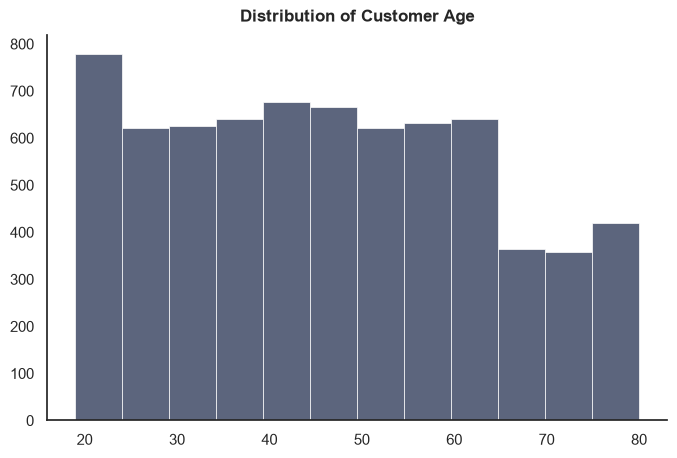

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    churn_df,
    x='Age',
    binwidth=5,
    color=colors['darkblue'],
    linewidth=0.5
)

plt.title('Distribution of Customer Age', pad=10, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.show()

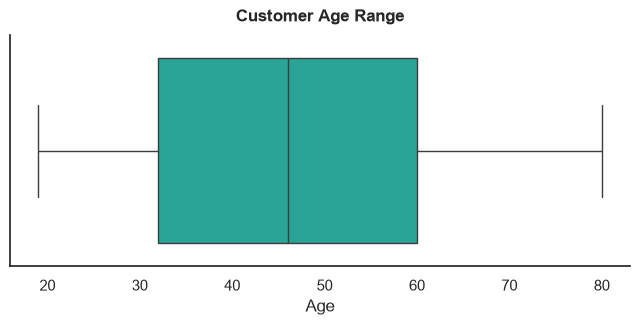

In [13]:
plt.figure(figsize=(8, 3))

sns.boxplot(
    churn_df,
    x='Age',
    color=colors['teal']
)

plt.title('Customer Age Range', pad=10, fontweight='bold')
plt.show()

#### Marital Status

- What proportion of customers are married versus unmarried?
- Is the customer base balanced by marital status?

In [14]:
churn_df['Married'].value_counts(normalize=True) * 100

Married
False    51.69672
True     48.30328
Name: proportion, dtype: Float64

#### Number of Dependents

- What proportion of customers have no dependents?
- How are customers distributed by number of dependents?
- What is the maximum number of dependents reported?

In [15]:
churn_df['Number of Dependents'].describe()

count      7043.0
mean     0.468692
std      0.962802
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           9.0
Name: Number of Dependents, dtype: Float64

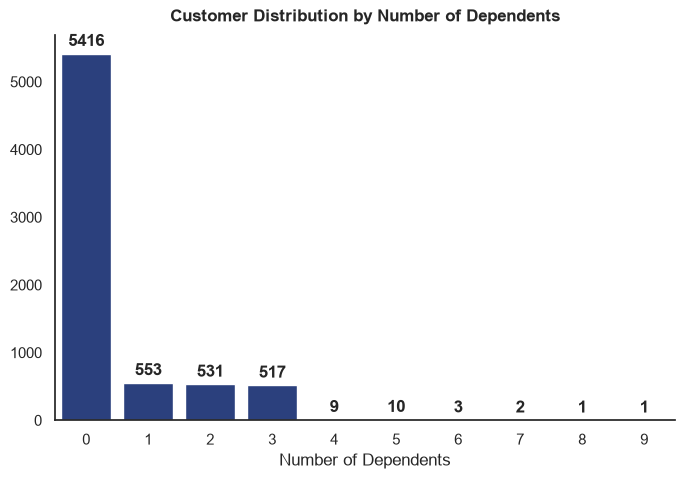

In [16]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    churn_df,
    x='Number of Dependents',
    color=colors['blue']
)

ax.bar_label(
    ax.containers[0],
    padding=3,
    fontweight='bold'
)

plt.title('Customer Distribution by Number of Dependents', fontweight='bold', pad=10)
plt.ylabel('')
plt.xlabel('Number of Dependents')
sns.despine()
plt.show()

In [191]:
churn_df['Number of Dependents'].value_counts(normalize=True) * 100

Number of Dependents
0    76.899049
1     7.851768
2     7.539401
3     7.340622
5     0.141985
4     0.127786
6     0.042595
7     0.028397
9     0.014198
8     0.014198
Name: proportion, dtype: Float64

### Demographic Observations

**Gender**
- The customer base is nearly evenly distributed by gender, with male customers accounting for approximately 50.5% and female customers accounting for 49.5%, indicating no notable gender imbalance.

**Age**
- Customer ages range from 19 to 80 years old, with an average age of approximately 46 years.
- The age distribution is relatively even across much of the age range, with a higher concentration among younger customers aged 19–25 and a gradual decline among customers aged 65–80. 
- The middle 50% of customers are between 32 and 60 years old.
- There are no apparent age outliers or implausible values in the records on age.

**Marital Status**
- Approximately 51.7% of customers are unmarried, while 48.3% are married, indicating that the customer base is relatively balanced in terms of marital status.

**Number of Dependents**
- Approximately 77% of customers report having no dependents.
- Customers with 1-3 dependents each account for approximately 7.5% of the customer base, while customers with 4 or more dependents collectively account for only about 1.5%.

### City
- How many unique cities are represented in the customer base?
- What are the top 10 cities with the most customers?
- What percentage of the customer base is concentrated in the top 10 cities?
- Is the customer base geographically concentrated or dispersed across cities?

In [193]:
churn_df['City'].nunique()

1106

Text(0.5, 0, '')

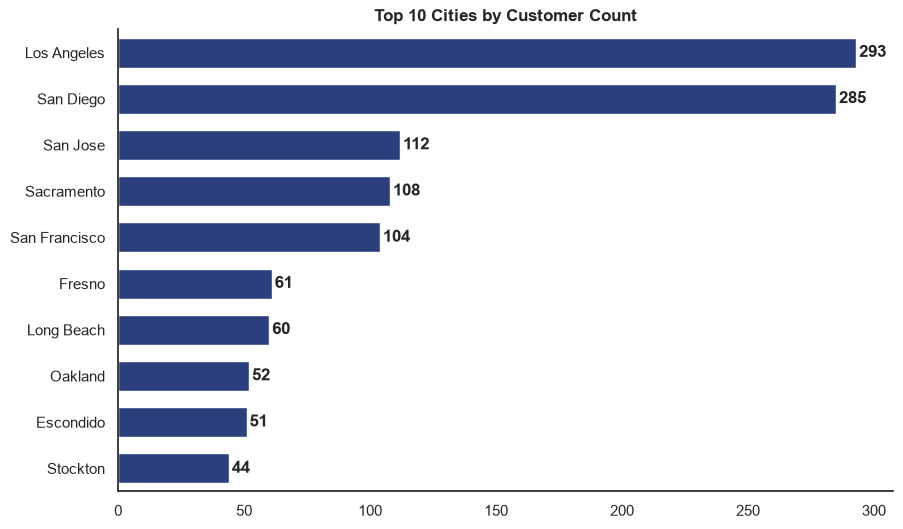

In [17]:
top10_cities = churn_df['City'].value_counts().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top10_cities.values,
    y=top10_cities.index,
    color=colors['blue'],
    width=0.65
)

ax.bar_label(
    ax.containers[0],
    padding=2,
    fontweight='bold'
)

plt.title('Top 10 Cities by Customer Count', fontweight='bold')
plt.ylabel('')
plt.xlabel('')

In [200]:
(top10_cities / len(churn_df)).sum() * 100

np.float64(16.612239102655117)

### Zip Code

- How many unique ZIP codes are represented in the customer base?
- How many customers are in the most frequently represented ZIP code?

In [231]:
churn_df['Zip Code'].nunique()

1626

In [234]:
churn_df['Zip Code'].value_counts()

Zip Code
92028    43
92027    38
92122    36
92117    34
92126    32
         ..
95431     2
92250     2
96150     2
91934     2
93711     1
Name: count, Length: 1626, dtype: int64[pyarrow]

### Geographic Observations

**City**
- The customer base spans 1,106 unique cities, indicating broad geographic coverage.
- Los Angeles and San Diego have the highest customer counts with 293 and 285 customers, respectively. 
- Despite this, the top 10 cities account for only 16.6% of the entire customer base, suggesting that customers are geographically dispersed rather than concentrated in a small number of cities.

**Zip Code**
- The ZIP code distribution further supports the geographic dispersion observed across cities. Customers are spread across 1,626 unique ZIP codes, with the most represented ZIP code containing only 43 customers.

### Number of Referrals
- What is the average number of referrals per customer?
- What proportion of customer have made no referrals?
- What is the maximum number of referrals made by a customer?
- How are customers distributed by number of referrals

In [235]:
churn_df['Number of Referrals'].describe()

count      7043.0
mean     1.951867
std      3.001199
min           0.0
25%           0.0
50%           0.0
75%           3.0
max          11.0
Name: Number of Referrals, dtype: Float64

In [238]:
churn_df['Number of Referrals'].value_counts(normalize=True).sort_index() * 100

Number of Referrals
0     54.252449
1     15.419566
2      3.350845
3      3.620616
4      3.350845
5      3.748403
6      3.137867
7      3.521227
8      3.024279
9      3.379242
10     3.166264
11     0.028397
Name: proportion, dtype: Float64

findfont: Failed to find font weight light, now using 400.


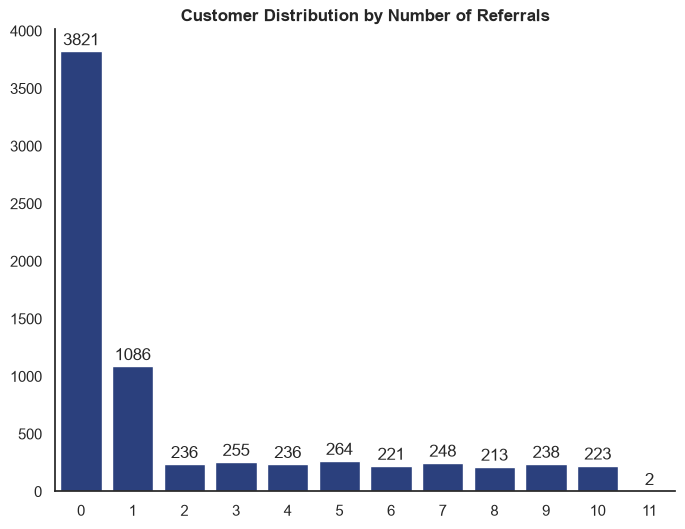

In [18]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    churn_df,
    x='Number of Referrals',
    color=colors['blue']
)

ax.bar_label(ax.containers[0],
             padding=2,
             fontweight='light')

plt.title('Customer Distribution by Number of Referrals', fontweight='bold')
plt.ylabel('')
plt.xlabel('')
plt.show()

### Tenure in Months
- What is the average and median custoemr tenure?
- What is the range of customer tenure?
- How are customers distributed across different tenure lengths?
- Are there any unusually low or high tenure values?

In [248]:
churn_df['Tenure in Months'].describe()

count       7043.0
mean     32.386767
std      24.542061
min            1.0
25%            9.0
50%           29.0
75%           55.0
max           72.0
Name: Tenure in Months, dtype: Float64

Text(0, 0.5, '')

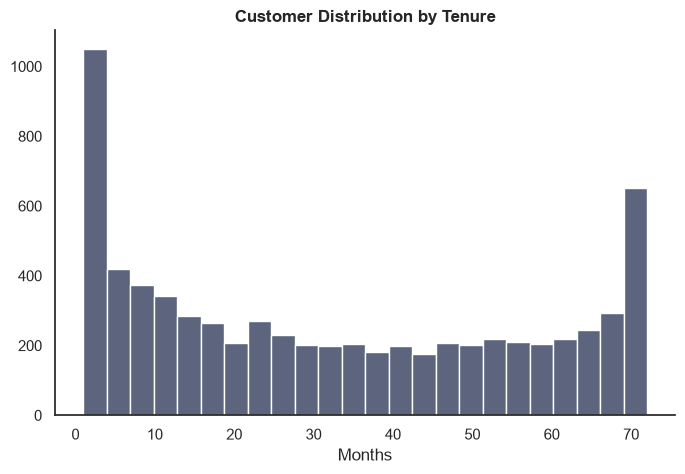

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    churn_df,
    x='Tenure in Months',
    binwidth=3,
    color=colors['darkblue']
)

plt.title('Customer Distribution by Tenure', fontweight='bold')
plt.xlabel('Months')
plt.ylabel('')

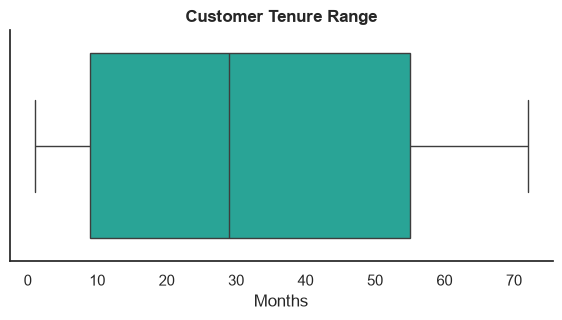

In [20]:
plt.figure(figsize=(7, 3))

sns.boxplot(
    churn_df,
    x='Tenure in Months',
    color=colors['teal']
)

plt.title('Customer Tenure Range', fontweight='bold')
plt.xlabel('Months')
plt.show()

### Customer Relationship Observations

**Number of Referrals**
- Customer referrals are heavily concentrated at the lower end, with approximately 54% of customers having made no referrals and around 15% having made only one.
- Customers with 2–10 referrals are less common and relatively evenly distributed, while the maximum number of referrals recorded is 11.

**Tenure in Months**
- Customer tenure ranges from 1 to 72 months, with an average tenure of approximately 32 months and a median of 29 months.
- The tenure distribution shows higher concentrations among both newer customers and long-tenured customers, particularly near the lower and upper ends of the range, rather than being concentrated around the middle.
- No unusually low or high tenure values are apparent from the distribution.

## Service Adoption

This section examines customer adoption across the company's phone, internet, and related service offerings.

In [21]:
service_columns = [
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music',
    'Unlimited Data'
]

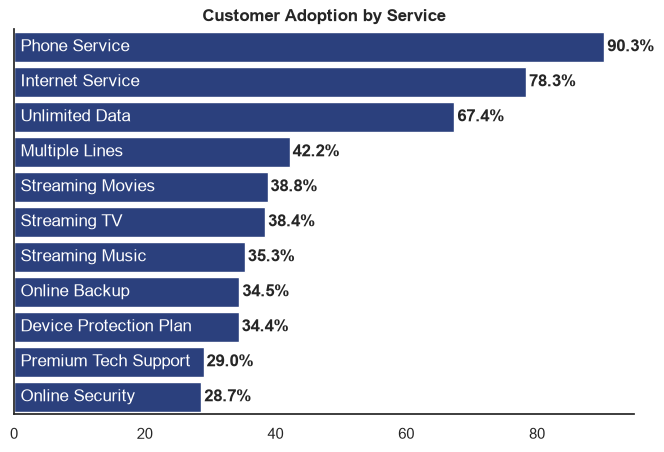

In [22]:
service_adoption = churn_df[service_columns].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=service_adoption.values,
    y=service_adoption.index,
    color=colors['blue'],
    width=0.85
)

ax.bar_label(ax.containers[0], 
             padding=2, 
             fontweight='bold',
             fmt='%.1f%%')

ax.set_yticks([])

for bar, label in zip(ax.patches, service_adoption.index):
    ax.text(
        1,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center',
        ha='left',
        color='white',
        fontweight='light'
    )
    
plt.title('Customer Adoption by Service', fontweight='bold')
plt.ylabel('')
plt.xlabel('')
sns.despine()
plt.show()

### Internet Type
- How are customers distributed across the different internet types?
- Which internet type is most commonly used?

In [23]:
churn_df['Internet Type'].value_counts()

Internet Type
Fiber Optic    3035
DSL            1652
None           1526
Cable           830
Name: count, dtype: int64

In [24]:
churn_df['Internet Type'].value_counts(normalize=True)

Internet Type
Fiber Optic    0.430924
DSL            0.234559
None           0.216669
Cable          0.117848
Name: proportion, dtype: float64

### Avg Monthly GB Download
- What is the average and median monthly GB downloaded by customers?
- How are monthly GB downloads distributed?
- What is the range of monthly GB downloads?
- Are there any unusually high values?

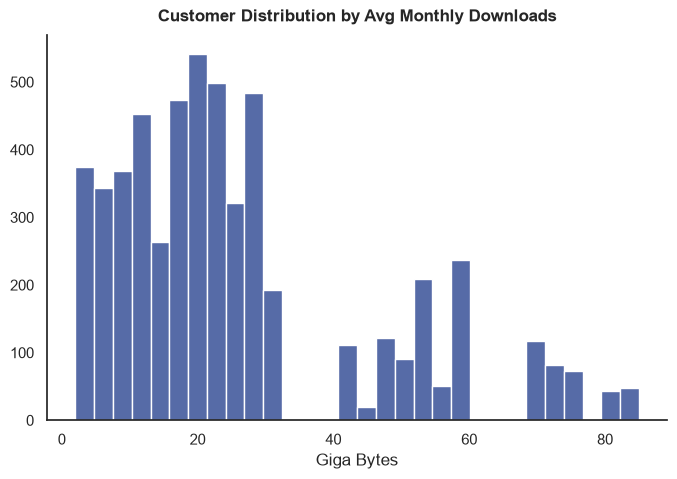

In [25]:
internet_customers = churn_df[churn_df['Internet Service']]

plt.figure(figsize=(8, 5))
sns.histplot(
    internet_customers,
    x='Avg Monthly GB Download',
    color=colors['blue'],
    bins=30
)

plt.ylabel('')
plt.xlabel('Giga Bytes')
plt.title('Customer Distribution by Avg Monthly Downloads', pad=10, fontweight='bold')
plt.show()

In [34]:
internet_customers['Avg Monthly GB Download'].describe()

count    5517.000000
mean       26.189959
std        19.586584
min         2.000000
25%        13.000000
50%        21.000000
75%        30.000000
max        85.000000
Name: Avg Monthly GB Download, dtype: float64

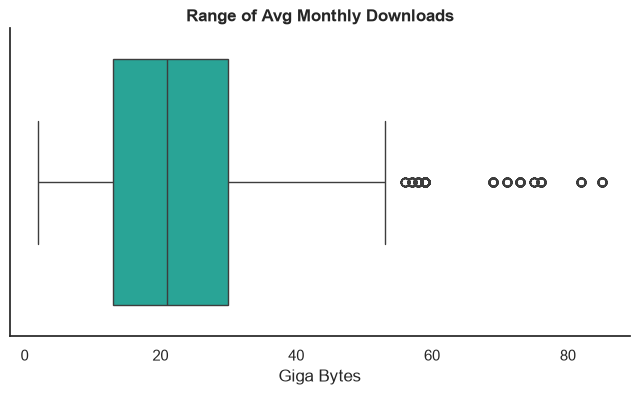

In [26]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    internet_customers,
    x='Avg Monthly GB Download',
    color=colors['teal']
)

plt.title('Range of Avg Monthly Downloads', fontweight='bold', pad=5)
plt.xlabel('Giga Bytes')
plt.show()

### Service Adoption Observations

**Overall Service Adoption**
- Service adoption is noticeably stronger for core connectivity services than for supplementary services. Phone Service and Internet Service are used by most customers, while features such as Online Security and Premium Tech Support are adopted by fewer than one-third of the customer base.
- Even among entertainment and convenience services, adoption remains below half of the customer base. This suggests that having internet service does not necessarily translate into customers subscribing to a broad range of additional services.
- Unlimited Data stands out from the other internet-related add-ons, with substantially higher adoption. This may indicate that customers place greater value on services directly related to their primary internet usage than on optional support, security, or entertainment features.
- The relatively low adoption of several add-on services leaves a large portion of the customer base without these services. Later analysis should investigate whether the number or type of services a customer subscribes to is associated with retention or churn.

**Internet Type**
- Fiber Optic accounts for the largest share of customers and is considerably more common than DSL or Cable. This makes Fiber Optic customers an especially important segment when examining customer behavior later in the analysis.
- Cable represents a relatively small portion of the customer base compared with the other connection types. Because the internet customer base is unevenly distributed across technologies, later comparisons between internet types should consider these differences in group size.

**Avg Monthly GB Download**
- Internet usage is concentrated primarily at lower-to-moderate monthly download levels, while a smaller group of customers exhibits substantially higher usage.
- Downloads above approximately 55 GB are statistical outliers under the IQR rule, but the repeated clusters of customers at higher usage levels suggest that these values may represent a genuine high-usage segment rather than isolated data errors.
- This variation indicates that internet customers do not form a single homogeneous usage group. Later analysis can examine whether different usage levels correspond with differences in service adoption, customer value, or churn behavior.

## Customer Offers and Contracts

This section examines customers' accepted marketing offers and contract arrangements.

### Offer
- Which marketing offer has the highest adoption among customers?
- What percentage of the customer base has not accepted any marketing offer?
- Which marketing offer has the lowest adoption among customers?

In [ ]:
churn_df['Offer'].value_counts()

Offer
None       3877
Offer B     824
Offer E     805
Offer D     602
Offer A     520
Offer C     415
Name: count, dtype: int64

In [37]:
churn_df['Offer'].value_counts(normalize=True) * 100

Offer
None       55.047565
Offer B    11.699560
Offer E    11.429788
Offer D     8.547494
Offer A     7.383217
Offer C     5.892375
Name: proportion, dtype: float64

### Contract

- How are customers distributed across the different contract types?
- Which contract type is most common among customers?
- What proportion of customers are on longer-term contracts?

In [38]:
churn_df['Contract'].value_counts()

Contract
Month-to-Month    3610
Two Year          1883
One Year          1550
Name: count, dtype: int64

In [39]:
churn_df['Contract'].value_counts(normalize=True) * 100

Contract
Month-to-Month    51.256567
Two Year          26.735766
One Year          22.007667
Name: proportion, dtype: float64

### Offers and Contracts Observations

**Offer**
- More than half of the customer base (55.0%) has not accepted any marketing offer, meaning offer adoption is relatively limited across the customer base.
- Among customers who have accepted an offer, no single offer dominates. Offers B and E have the highest adoption, while Offer C has the lowest, suggesting that customer participation is spread across several offers rather than being driven by one particularly dominant offer.

**Contract**
- The customer base leans toward shorter contractual commitments, with 51.3% of customers on month-to-month contracts compared with 48.7% collectively on one- or two-year contracts.
- Among longer-term contracts, two-year agreements are somewhat more common than one-year agreements, indicating that customers who do make a longer commitment are not necessarily concentrated in the shorter one-year option.

## Billing and Financial Profile

This section examines customer charges, revenue, refunds, and payment characteristics to understand the financial profile of the customer base.

### Monthly Charge
- What is the average and median monthly charge?
- How are monthly charges distributed among the customer base?
- What is the range of monthly charges?
- How many of the customers has a negative monthly charge?

In [5]:
churn_df['Monthly Charge'].describe()

count    7043.000000
mean       63.596134
std        31.204744
min       -10.000000
25%        30.400000
50%        70.050003
75%        89.750000
max       118.750000
Name: Monthly Charge, dtype: float64

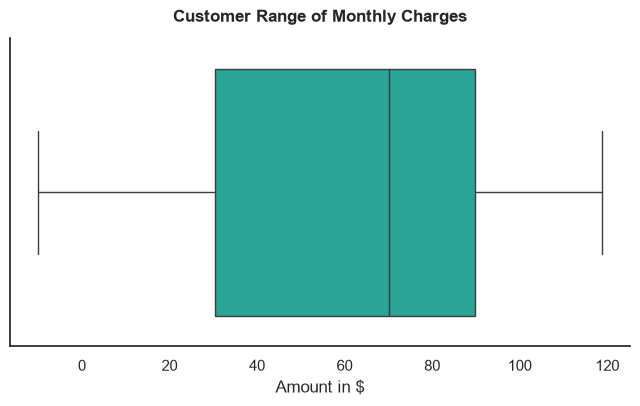

In [27]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    churn_df,
    x='Monthly Charge',
    color=colors['teal']
)

plt.title('Customer Range of Monthly Charges', pad=12, fontweight='bold')
plt.xlabel('Amount in $')
plt.show()

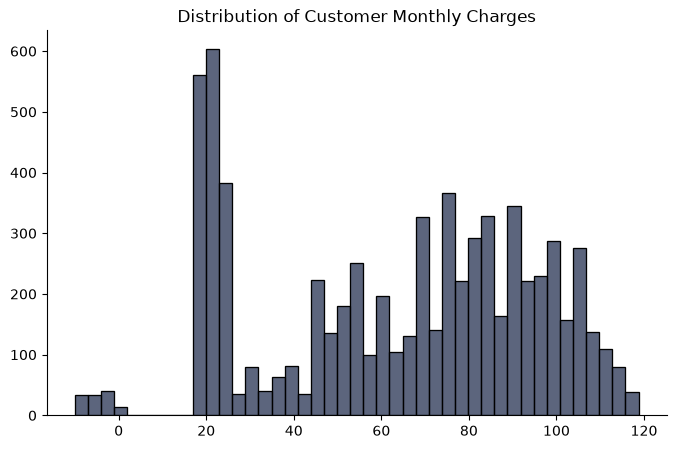

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    churn_df,
    x='Monthly Charge',
    color=colors['darkblue'],
    binwidth=3
)

plt.title('Distribution of Customer Monthly Charges')
plt.xlabel('')
plt.ylabel('')
plt.show()

### Total Charges
- What is the average and median Total Charges?
- What is the range of  Total Charges?
- Are there any unusual or outliers in terms of Total Charges?
- How are Total Charges distributed among the customers?

In [11]:
churn_df['Total Charges'].describe()

count    7043.000000
mean     2280.381348
std      2266.220459
min        18.799999
25%       400.149994
50%      1394.550049
75%      3786.599976
max      8684.799805
Name: Total Charges, dtype: float64

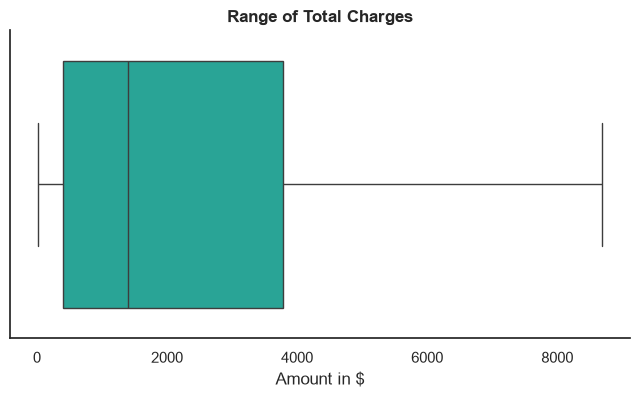

In [28]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    churn_df,
    x='Total Charges',
    color=colors['teal']
)

plt.title('Range of Total Charges', fontweight='bold')
plt.xlabel('Amount in $')
plt.show()

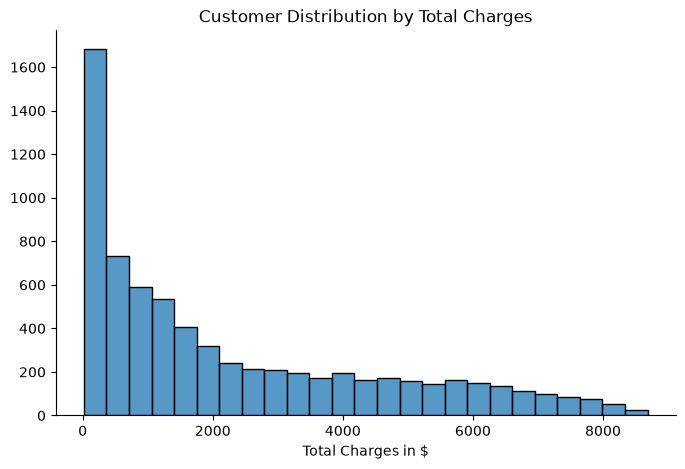

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(
    churn_df,
    x='Total Charges'
)

plt.title('Customer Distribution by Total Charges')
plt.xlabel('Total Charges in $')
plt.ylabel('')
sns.despine()
plt.show()

### Monthly Charge

- The average monthly charge billed to a customer is $63.59, with a median of $70.05.
- Monthly charges range from -$10.00 to $118.75. Although no values are identified as statistical outliers, the negative charges remain unusual and warrant further examination.
- The middle 50% of customers have monthly charges between $31.00 and $89.75.
- Customers appear to cluster around different billing levels rather than around one typical monthly charge.
- A particularly high concentration of customers has monthly charges around $20.

### Total Charges

- The average total charges incurred by a customer is $2,280.38, while the median is considerably lower at $1,394.55.
- Total charges are highly right-skewed, with customers concentrated toward lower total charges and progressively fewer customers at higher values.
- The substantial difference between the mean and median reflects this right-skew, as customers with higher accumulated charges pull the average upward. Therefore, the median may better represent the typical customer's total charges.
- The middle 50% of customers have accumulated total charges between approximately $400.00 and $3,786.60.
- Total charges range from $18.79 to $8,684.79, with no apparent statistical outliers.
- The wide variation in total charges may reflect differences in both customers' monthly charges and the length of time they have been with the company. The relationship between total charges and customer tenure can be investigated further in later analysis.

In [29]:
churn_df['Total Revenue'].describe()

count     7043.000000
mean      3034.379150
std       2865.204590
min         21.360001
25%        605.609985
50%       2108.639893
75%       4801.145020
max      11979.339844
Name: Total Revenue, dtype: float64

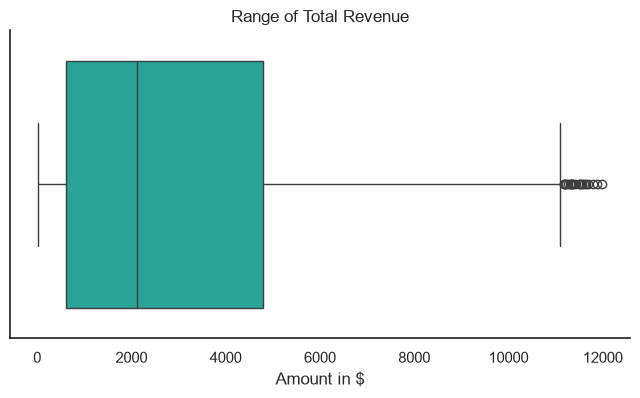

In [30]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    churn_df,
    x='Total Revenue',
    color=colors['teal']
)

plt.title('Range of Total Revenue')
plt.ylabel('')
plt.xlabel('Amount in $')
plt.show()

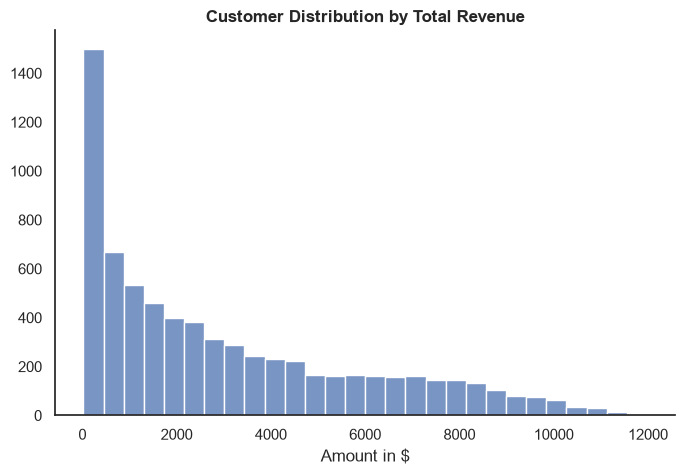

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(
    churn_df,
    x='Total Revenue'
)

plt.title('Customer Distribution by Total Revenue', fontweight='bold')
plt.ylabel('')
plt.xlabel('Amount in $')
plt.show()

In [4]:
churn_df['Total Refunds'].describe()

count    7043.000000
mean        1.962182
std         7.902614
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        49.790001
Name: Total Refunds, dtype: float64

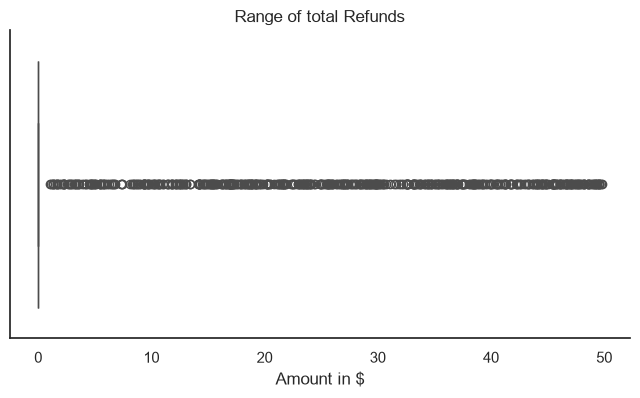

In [5]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    churn_df,
    x='Total Refunds'
)

plt.title('Range of total Refunds')
plt.ylabel('')
plt.xlabel('Amount in $')
plt.show()

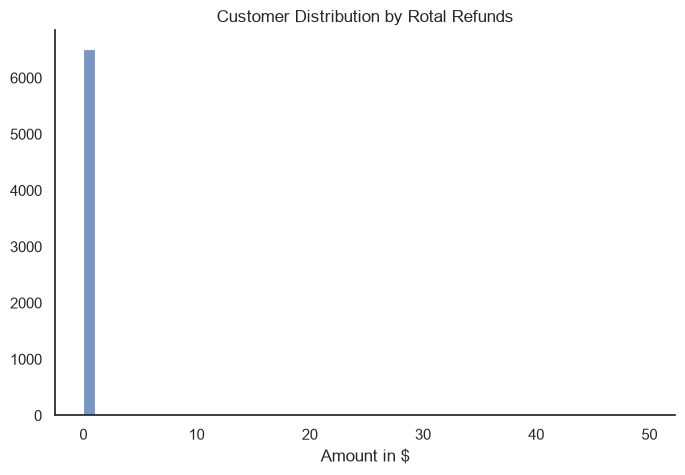

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    churn_df,
    x='Total Refunds',
    bins=50
)

plt.title('Customer Distribution by Total Refunds')
plt.ylabel('')
plt.xlabel('Amount in $')
plt.show()

In [8]:
churn_df['Total Refunds'].value_counts()

Total Refunds
0.000000     6518
44.900002       2
9.730000        2
16.559999       2
8.740000        2
             ... 
26.980000       1
31.389999       1
16.360001       1
9.360000        1
10.200000       1
Name: count, Length: 500, dtype: int64

In [11]:
refunded_customers = churn_df[churn_df['Total Refunds'] != 0]

refunded_customers['Total Refunds'].describe()

count    525.000000
mean      26.323143
std       14.028475
min        1.010000
25%       15.240000
50%       25.980000
75%       38.369999
max       49.790001
Name: Total Refunds, dtype: float64

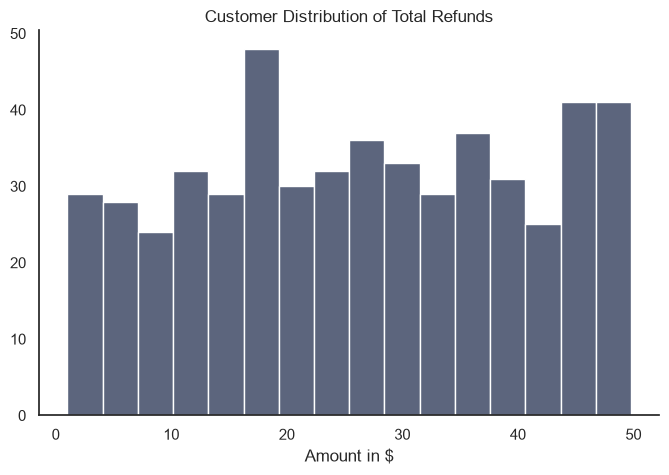

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    refunded_customers,
    x='Total Refunds',
    binwidth=3,
    color=colors['darkblue']
)

plt.title('Customer Distribution of Total Refunds')
plt.xlabel('Amount in $')
plt.ylabel('')
plt.show()

In [22]:
extra_data_customers = churn_df[churn_df['Total Extra Data Charges'] != 0]

extra_data_customers['Total Extra Data Charges'].describe()

count        728.0
mean     66.373626
std      46.361809
min           10.0
25%           20.0
50%           60.0
75%          100.0
max          150.0
Name: Total Extra Data Charges, dtype: Float64

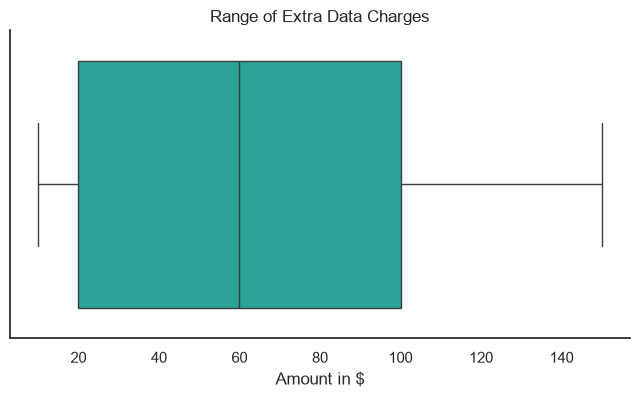

In [24]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    extra_data_customers,
    x='Total Extra Data Charges',
    color=colors['teal']
)

plt.title('Range of Extra Data Charges')
plt.ylabel('')
plt.xlabel('Amount in $')
plt.show()

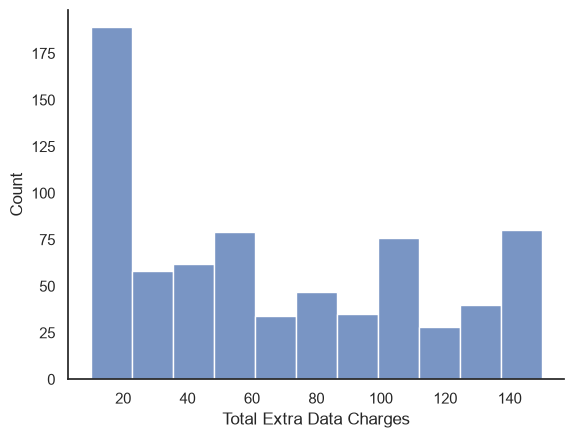

In [26]:
sns.histplot(
    extra_data_customers,
    x='Total Extra Data Charges'
)

plt.show()


In [28]:
churn_df['Avg Monthly Long Distance Charges'].describe()

count    7043.000000
mean       22.958954
std        15.448113
min         0.000000
25%         9.210000
50%        22.889999
75%        36.395000
max        49.990002
Name: Avg Monthly Long Distance Charges, dtype: float64

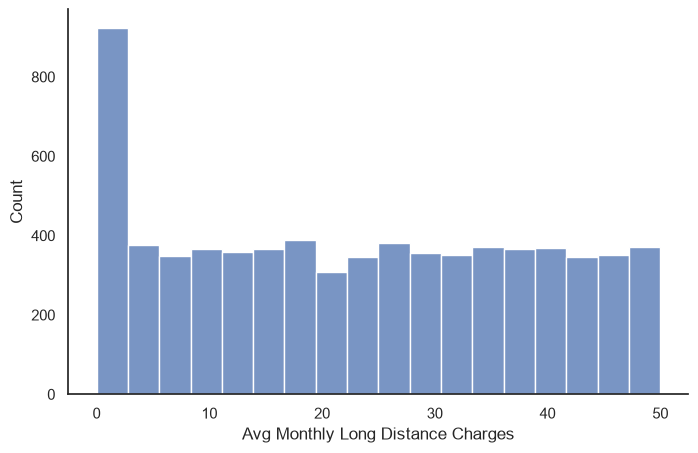

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(
    churn_df,
    x='Avg Monthly Long Distance Charges'
)

plt.show()

In [4]:
payment_method = churn_df['Payment Method'].value_counts(normalize=True) * 100
payment_method

Payment Method
Bank Withdrawal    55.501917
Credit Card        39.031663
Mailed Check        5.466421
Name: proportion, dtype: float64

In [6]:
churn_df['Payment Method'].value_counts()

Payment Method
Bank Withdrawal    3909
Credit Card        2749
Mailed Check        385
Name: count, dtype: int64

In [10]:
paperless_billing = pd.DataFrame({
    'Count': churn_df['Paperless Billing'].value_counts(),
    'Percentage': churn_df['Paperless Billing'].value_counts(normalize=True) * 100}
)

paperless_billing

,Count,Percentage
Paperless Billing,,
True,4171,59.221922
False,2872,40.778078


## Customer Status and Churn Profile

This section examines the overall distribution of customer statuses and the documented categories and reasons associated with customer churn.